<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9; border-right: 5px solid #20639b; padding: 8px 18px;">
  <h1 style="color:#173f5f; margin-bottom:4px;">نوت‌بوک 19: مصورسازی داده با Matplotlib</h1>
  <p><b>سطح:</b> مقدماتی تا متوسط &nbsp; | &nbsp; <b>روش مطالعه:</b> توضیح کوتاه ← اجرای مثال ← تغییر مثال ← حل تمرین</p>
  <h3>هدف‌های یادگیری</h3>
  <ul><li>درک Figure و Axes</li>
<li>رسم نمودار خطی، میله‌ای، پراکندگی و هیستوگرام</li>
<li>ساخت subplot و شخصی‌سازی خوانا</li>
<li>انتخاب نمودار مناسب برای سؤال تحلیلی</li></ul>
  <p style="background:#eef6fb; padding:10px; border-radius:8px;">همهٔ سلول‌ها را به‌ترتیب اجرا کنید. برای یادگیری بهتر، مقدار ورودی‌ها را تغییر دهید و نتیجه را پیش‌بینی کنید.</p>
</div>

<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">Figure و Axes</h2>
  <p>Figure بوم کامل و Axes ناحیهٔ رسم است. روش شیءگرا با <code>fig, ax = plt.subplots()</code> برای پروژه‌های واقعی خواناتر و قابل کنترل‌تر است.</p>
</div>

In [1]:
# Prepare plotting tools and sample data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = np.array([120, 145, 138, 170, 190, 210])


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">نمودار خطی</h2>
  <p>نمودار خطی برای روند زمانی مناسب است. عنوان، نام محورها و واحد داده باید روشن باشند.</p>
</div>

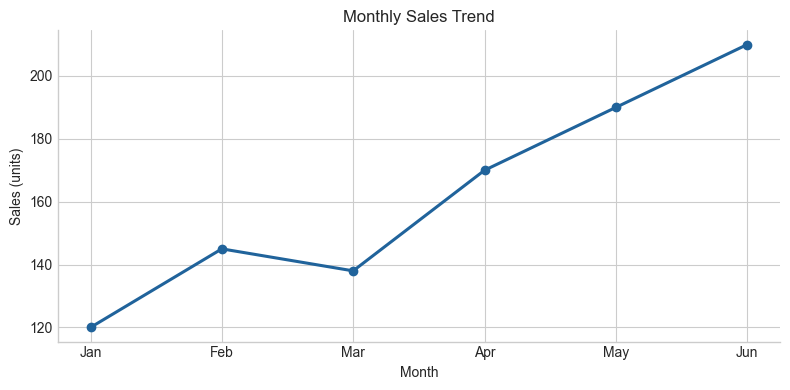

In [2]:
# Plot a time trend
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(months, sales, marker="o", linewidth=2.2, color="#20639b")
ax.set(title="Monthly Sales Trend", xlabel="Month", ylabel="Sales (units)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">نمودار میله‌ای</h2>
  <p>نمودار میله‌ای برای مقایسهٔ دسته‌ها مناسب است. مرتب‌سازی داده، مقایسه را آسان‌تر می‌کند.</p>
</div>

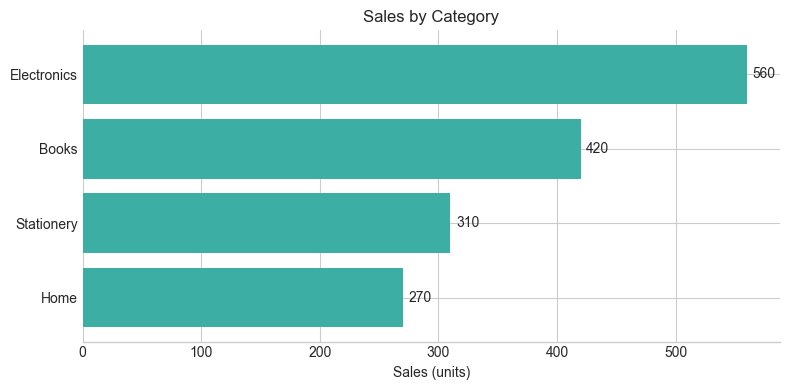

In [3]:
# Compare categories with a sorted bar chart
category_sales = pd.Series({
    "Books": 420,
    "Stationery": 310,
    "Electronics": 560,
    "Home": 270,
}).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(category_sales.index, category_sales.values, color="#3caea3")
ax.bar_label(bars, padding=4)
ax.set(title="Sales by Category", xlabel="Sales (units)")
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">پراکندگی و هیستوگرام</h2>
  <p>Scatter رابطهٔ دو متغیر و Histogram توزیع یک متغیر را نشان می‌دهد.</p>
</div>

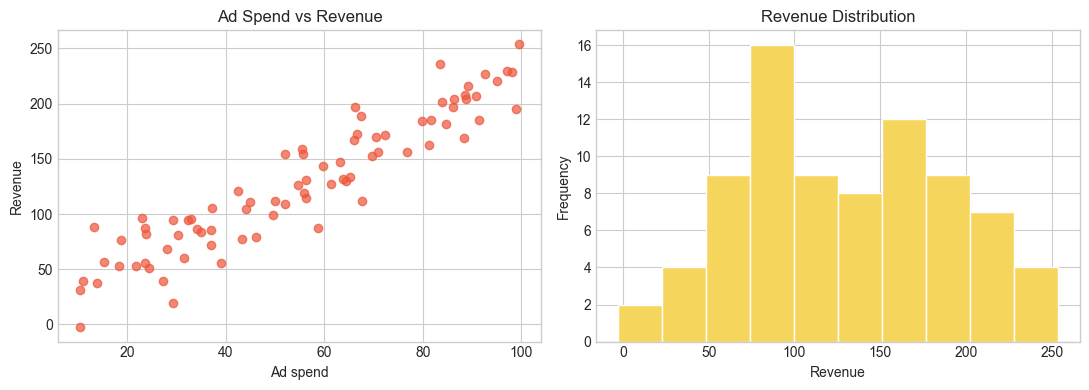

In [4]:
# Generate reproducible customer data
rng = np.random.default_rng(7)
ad_spend = rng.uniform(10, 100, 80)
revenue = 2.4 * ad_spend + rng.normal(0, 25, 80)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(ad_spend, revenue, alpha=0.7, color="#ed553b")
axes[0].set(title="Ad Spend vs Revenue", xlabel="Ad spend", ylabel="Revenue")

axes[1].hist(revenue, bins=10, color="#f6d55c", edgecolor="white")
axes[1].set(title="Revenue Distribution", xlabel="Revenue", ylabel="Frequency")

fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">چند نمودار در یک Figure</h2>
  <p>subplot برای نمایش چند زاویهٔ مرتبط از یک داده مناسب است. محور مشترک و رنگ ثابت به یکپارچگی کمک می‌کند.</p>
</div>

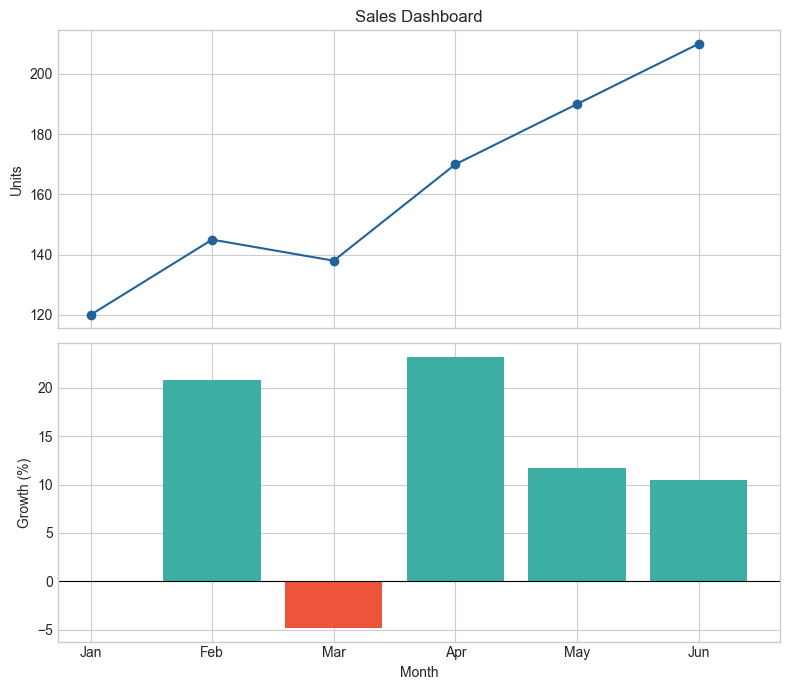

In [5]:
# Compare actual values and monthly growth
growth_pct = np.r_[np.nan, np.diff(sales) / sales[:-1] * 100]

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(months, sales, marker="o", color="#20639b")
axes[0].set(title="Sales Dashboard", ylabel="Units")

colors = ["#3caea3" if value >= 0 else "#ed553b" for value in growth_pct[1:]]
axes[1].bar(months[1:], growth_pct[1:], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(xlabel="Month", ylabel="Growth (%)")

fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">متن فارسی در نمودار</h2>
  <p>نمایش درست فارسی به فونت فارسی و گاهی کتابخانه‌های شکل‌دهی متن نیاز دارد. برای محیط‌های مختلف، فونت را از روی نام یا فایل فونت تنظیم کنید. در این مجموعه برچسب نمودارها انگلیسی نگه داشته شده‌اند تا بدون وابستگی اضافی اجرا شوند.</p>
</div>

<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">تمرین کوتاه</h2>
  <div style="background:#fff7df; border:1px solid #f0c36d; padding:12px; border-radius:8px;">با دادهٔ فروش ماهانه، یک نمودار ترکیبی تمیز بسازید: فروش به‌صورت میله و میانگین متحرک سه‌ماهه به‌صورت خط. عنوان، راهنما و برچسب محورها را اضافه کنید.</div>
</div>

<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">پاسخ پیشنهادی</h2>
  <p>ابتدا پاسخ خودتان را بنویسید؛ سپس این سلول را اجرا و مقایسه کنید.</p>
</div>

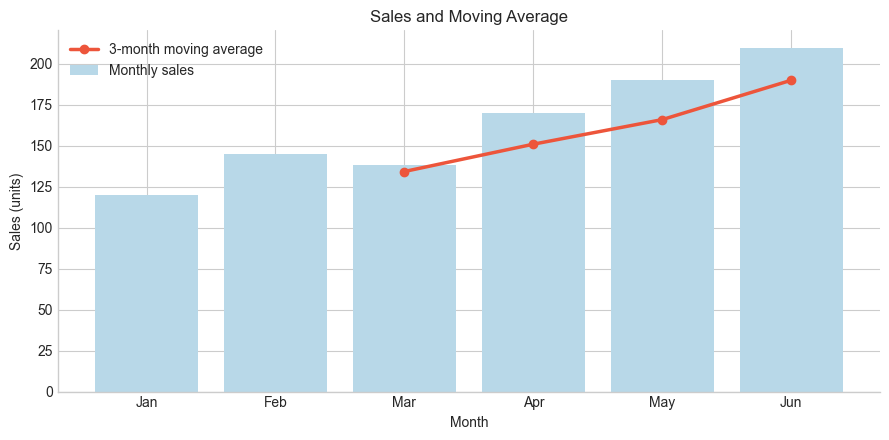

In [6]:
# Combine bars with a three-month moving average
sales_series = pd.Series(sales, index=months)
moving_average = sales_series.rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(months, sales, color="#b8d8e8", label="Monthly sales")
ax.plot(
    months,
    moving_average,
    color="#ed553b",
    marker="o",
    linewidth=2.5,
    label="3-month moving average",
)
ax.set(title="Sales and Moving Average", xlabel="Month", ylabel="Sales (units)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">انتخاب نمودار</h2>
  <p><b>روند:</b> خطی؛ <b>مقایسهٔ دسته‌ها:</b> میله‌ای؛ <b>رابطه:</b> پراکندگی؛ <b>توزیع:</b> هیستوگرام. نمودار باید به یک سؤال مشخص پاسخ دهد.</p>
</div>